##Emotion-Aware Input Encoding + Full Comparison


## Section 1: Install & Imports

In [1]:
!pip install -q transformers datasets rouge-score nltk sentencepiece accelerate vaderSentiment scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.0 MB/s eta 0:00:00


In [3]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

import os, ast, re, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import (BartTokenizer, BartForConditionalGeneration,
                          BartModel, BartConfig,
                          pipeline, get_linear_schedule_with_warmup)
from torch.optim import AdamW
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4



## Section 2: Mount Drive & Configuration

In [4]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH    = '/content/drive/MyDrive/NeuralNetworks/Project/Dataset/train.csv'
BASELINE_DIR = '/content/drive/MyDrive/NeuralNetworks/Project/checkpoints/baseline'
S1_DIR       = '/content/drive/MyDrive/NeuralNetworks/Project/checkpoints/EmoToken'
SAVE_DIR     = '/content/drive/MyDrive/NeuralNetworks/Project/checkpoints/EmoFusion'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_NAME     = 'facebook/bart-base'
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 64
BATCH_SIZE     = 8
GRAD_ACCUM     = 4
EPOCHS         = 5
LR             = 3e-5
WARMUP_STEPS   = 100
SUBSET         = None
EMO_EMB_DIM    = 128

EMOTION_MAP = {
    0: "neutral",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}
N_EMOTIONS = len(EMOTION_MAP)

Mounted at /content/drive



## Section 3: Data Parsing

In [5]:
def parse_array_string(s):
    return [int(x) for x in s.strip().strip('[]').split()]

def parse_dialog_string(s):
    s = s.strip()
    if s.startswith('['):
        s = s[1:]
    if s.endswith(']'):
        s = s[:-1]
    parts = re.split(r"""['"']\s*\n\s*['"']""", s)
    turns = []
    for part in parts:
        cleaned = part.strip().strip("'\"").strip()
        if cleaned:
            turns.append(cleaned)
    return turns if len(turns) >= 2 else None

def build_pairs(df, context_window=3):
    pairs = []
    for _, row in df.iterrows():
        turns    = parse_dialog_string(row['dialog'])
        emotions = parse_array_string(row['emotion'])
        if turns is None or len(turns) < 2 or len(turns) != len(emotions):
            continue
        for i in range(1, len(turns)):
            ctx = ' [SEP] '.join(turns[max(0, i - context_window):i])
            pairs.append({
                'context':       ctx,
                'response':      turns[i],
                'emotion':       emotions[i],
                'emotion_label': EMOTION_MAP[emotions[i]]
            })
    return pairs

df_raw = pd.read_csv(DATA_PATH)

all_pairs = build_pairs(df_raw)
random.shuffle(all_pairs)
n = len(all_pairs)
train_pairs = all_pairs[:int(0.8*n)]
val_pairs   = all_pairs[int(0.8*n):int(0.9*n)]
test_pairs  = all_pairs[int(0.9*n):]
print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

emo_counts = Counter(p['emotion_label'] for p in train_pairs)
print('\nEmotion distribution (train):')
for emo, cnt in sorted(emo_counts.items()):
    print(f'  {emo:12s}: {cnt:5d} ({cnt/len(train_pairs)*100:.1f}%)')

Train: 24840 | Val: 3105 | Test: 3106

Emotion distribution (train):
  anger       :   282 (1.1%)
  disgust     :    96 (0.4%)
  fear        :    39 (0.2%)
  happiness   :  3156 (12.7%)
  neutral     : 20564 (82.8%)
  sadness     :   249 (1.0%)
  surprise    :   454 (1.8%)



## Section 4: EmoFusion — Emotion-Aware Encoder Model

We wrap `BartForConditionalGeneration` with a small emotion embedding layer.
The emotion label (integer 0-6) is looked up in a learned embedding table (dim=128),
projected to BART's hidden size (768), and **added to every token's encoder input embedding**.
This means every encoder attention head sees emotion-modulated representations
throughout all 12 layer.

In [6]:
class EmotionAwareBart(nn.Module):
    """
    Architecture:
    - Base: BartForConditionalGeneration (frozen pre-trained weights initially)
    - Added: Emotion embedding table (7 emotions x EMO_EMB_DIM)
    - Added: Linear projection (EMO_EMB_DIM -> 768, BART hidden size)
    - At forward pass: emotion embedding is projected and added to
      the encoder's input embeddings before the transformer layers
    """
    def __init__(self, model_name, n_emotions, emo_emb_dim, hidden_size=768):
        super().__init__()
        self.bart       = BartForConditionalGeneration.from_pretrained(model_name)
        self.emo_embed  = nn.Embedding(n_emotions, emo_emb_dim)
        self.emo_proj   = nn.Linear(emo_emb_dim, hidden_size)
        # Initialize emotion projection with small weights
        nn.init.normal_(self.emo_embed.weight, mean=0, std=0.02)
        nn.init.zeros_(self.emo_proj.bias)
        nn.init.normal_(self.emo_proj.weight, mean=0, std=0.02)

    def forward(self, input_ids, attention_mask, emotion_ids, labels=None):
        # Get BART's token embeddings for the encoder input
        # Shape: (batch, seq_len, 768)
        token_embeds = self.bart.model.shared(input_ids)

        # Get emotion embedding and project to hidden size
        # Shape: (batch, EMO_EMB_DIM) -> (batch, 768)
        emo_emb = self.emo_embed(emotion_ids)          # (batch, emo_emb_dim)
        emo_vec = self.emo_proj(emo_emb)               # (batch, 768)

        # Add emotion vector to every token position in the encoder input
        # Unsqueeze to (batch, 1, 768) then broadcast across seq_len
        fused_embeds = token_embeds + emo_vec.unsqueeze(1)

        # Pass fused embeddings through BART encoder and decoder
        outputs = self.bart(
            inputs_embeds=fused_embeds,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs

    def generate(self, input_ids, attention_mask, emotion_ids, **gen_kwargs):
        """Generation wrapper — fuses emotion before calling bart.generate."""
        token_embeds = self.bart.model.shared(input_ids)
        emo_emb = self.emo_embed(emotion_ids)
        emo_vec = self.emo_proj(emo_emb)
        fused_embeds = token_embeds + emo_vec.unsqueeze(1)
        return self.bart.generate(
            inputs_embeds=fused_embeds,
            attention_mask=attention_mask,
            **gen_kwargs
        )

tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)

model = EmotionAwareBart(
    model_name=MODEL_NAME,
    n_emotions=N_EMOTIONS,
    emo_emb_dim=EMO_EMB_DIM
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
new_params       = sum(p.numel() for p in model.emo_embed.parameters()) + \
                   sum(p.numel() for p in model.emo_proj.parameters())
print(f'Total parameters:     {total_params/1e6:.2f}M')
print(f'New emotion params:   {new_params:,} (embed + projection)')
print(f'Base BART params:     {(total_params-new_params)/1e6:.2f}M')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Total parameters:     139.52M
New emotion params:   99,968 (embed + projection)
Base BART params:     139.42M



## Section 5: Dataset & DataLoaders

In [7]:
class EmotionEncoderDataset(Dataset):
    """
    Returns emotion as an integer tensor (used as index into emo_embed).
    Context and response are tokenized normally — no special tokens prepended.
    """
    def __init__(self, pairs, tokenizer, max_input_len, max_target_len):
        self.pairs         = pairs
        self.tokenizer     = tokenizer
        self.max_input_len  = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        enc = self.tokenizer(
            pair['context'],
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        dec = self.tokenizer(
            pair['response'],
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        labels = dec['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         labels,
            'emotion_ids':    torch.tensor(pair['emotion'], dtype=torch.long),
            'emotion_label':  pair['emotion_label']
        }

train_dataset = EmotionEncoderDataset(train_pairs, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
val_dataset   = EmotionEncoderDataset(val_pairs,   tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
test_dataset  = EmotionEncoderDataset(test_pairs,  tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

sample = train_dataset[0]

Train batches: 3105 | Val: 389 | Test: 389



## Section 6: Training with Weighted Loss

In [8]:
# Compute inverse-frequency weights for the emotion embedding
# (weights the emotion embedding loss contribution, not vocab loss)
counts   = Counter(p['emotion'] for p in train_pairs)
total    = sum(counts.values())
emo_sample_weights = {
    idx: total / (N_EMOTIONS * counts.get(idx, 1))
    for idx in range(N_EMOTIONS)
}
# Normalize
mean_w = np.mean(list(emo_sample_weights.values()))
emo_sample_weights = {k: v/mean_w for k, v in emo_sample_weights.items()}
print('Sample weights per emotion:')
for idx, name in EMOTION_MAP.items():
    print(f'  {name:12s}: {emo_sample_weights[idx]:.3f}')

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps
)

def train_one_epoch(model, loader, optimizer, scheduler, device, grad_accum, sample_weights):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Training')):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        emotion_ids    = batch['emotion_ids'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            emotion_ids=emotion_ids,
            labels=labels
        )

        # Scale loss by per-sample emotion weight
        # This upweights minority emotion samples during backprop
        batch_weights = torch.tensor(
            [sample_weights[e.item()] for e in emotion_ids],
            dtype=torch.float, device=device
        )
        loss = (outputs.loss * batch_weights.mean()) / grad_accum
        loss.backward()
        total_loss += outputs.loss.item()

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

    return total_loss / len(loader)

def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                emotion_ids=batch['emotion_ids'].to(device),
                labels=batch['labels'].to(device)
            )
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

Sample weights per emotion:
  neutral     : 0.007
  anger       : 0.537
  disgust     : 1.579
  fear        : 3.886
  happiness   : 0.048
  sadness     : 0.609
  surprise    : 0.334



===== EPOCH 1/5 =====


Training:   0%|          | 0/3105 [00:00<?, ?it/s]

Validation:   0%|          | 0/389 [00:00<?, ?it/s]

Train Loss: 3.1164 | Val Loss: 2.7053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training:   0%|          | 0/3105 [00:00<?, ?it/s]

Validation:   0%|          | 0/389 [00:00<?, ?it/s]

Train Loss: 2.6111 | Val Loss: 2.5693


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  --> Saved best model to /content/drive/MyDrive/NeuralNetworks/Project/checkpoints/EmoFusion

Best Val Loss: 2.5693


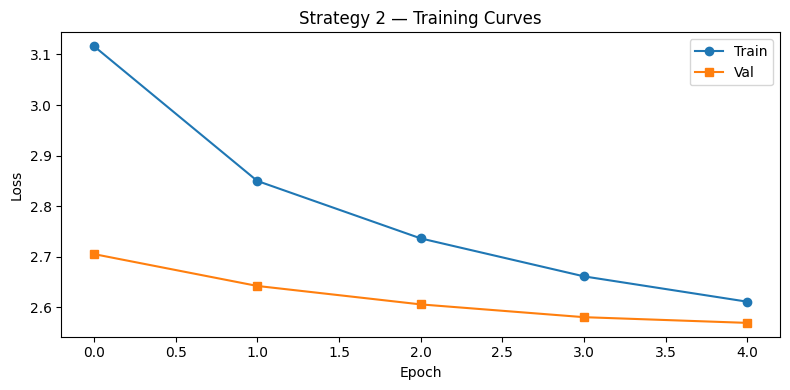

In [9]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    print(f'\n===== EPOCH {epoch}/{EPOCHS} =====')
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler,
                                  DEVICE, GRAD_ACCUM, emo_sample_weights)
    val_loss   = evaluate_loss(model, val_loader, DEVICE)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'emo_embed': model.emo_embed.state_dict(),
            'emo_proj':  model.emo_proj.state_dict()
        }, os.path.join(SAVE_DIR, 'emotion_layers.pt'))
        model.bart.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f'  --> Saved best model to {SAVE_DIR}')

print(f'\nBest Val Loss: {best_val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(history['train_loss'], label='Train', marker='o')
plt.plot(history['val_loss'],   label='Val',   marker='s')
plt.title('Strategy 2 — Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves_EmoFusion.png'), dpi=150)
plt.show()


## Section 7: Load Best Checkpoint & Generate

In [10]:
# Reload best checkpoint
model.bart = BartForConditionalGeneration.from_pretrained(SAVE_DIR)
emo_ckpt   = torch.load(os.path.join(SAVE_DIR, 'emotion_layers.pt'), map_location='cpu')
model.emo_embed.load_state_dict(emo_ckpt['emo_embed'])
model.emo_proj.load_state_dict(emo_ckpt['emo_proj'])
model = model.to(DEVICE)
model.eval()

def generate_EmoFusion(model, tokenizer, pairs, device,
                        batch_size=16, max_input_len=128, max_gen_len=64,
                        num_beams=4, no_repeat_ngram_size=3):
    all_generated = []
    for i in tqdm(range(0, len(pairs), batch_size), desc='Generating'):
        batch_pairs = pairs[i:i+batch_size]
        contexts    = [p['context']  for p in batch_pairs]
        emo_ids     = torch.tensor([p['emotion'] for p in batch_pairs],
                                    dtype=torch.long, device=device)

        enc = tokenizer(
            contexts, max_length=max_input_len,
            padding=True, truncation=True, return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            out_ids = model.generate(
                input_ids=enc['input_ids'],
                attention_mask=enc['attention_mask'],
                emotion_ids=emo_ids,
                max_new_tokens=max_gen_len,
                num_beams=num_beams,
                no_repeat_ngram_size=no_repeat_ngram_size,
                early_stopping=True
            )
        decoded = tokenizer.batch_decode(out_ids, skip_special_tokens=True)
        all_generated.extend(decoded)
    return all_generated

print(f'Generating for {len(test_pairs)} test pairs...')
generated_s2 = generate_EmoFusion(model, tokenizer, test_pairs, DEVICE)
references   = [p['response'] for p in test_pairs]

print('\n--- Sample outputs ---')
for i in range(4):
    print(f'\n[{i+1}] Emotion  : {test_pairs[i]["emotion_label"]}')
    print(f'    Context  : {test_pairs[i]["context"][:80]}')
    print(f'    Reference: {references[i]}')
    print(f'    Generated: {generated_s2[i]}')

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Generating for 3106 test pairs...


Generating:   0%|          | 0/195 [00:00<?, ?it/s]


--- Sample outputs ---

[1] Emotion  : happiness
    Context  : Oh . I just wanted you to shut up . You were off-key anyway . Let me see that ! 
    Reference: What a cool see-through blue ! How do you wear this thing ?
    Generated: I'm sorry , but I didn't mean to be .

[2] Emotion  : surprise
    Context  : Don ’ t be intimidated . There is a lot to sign , but I will explain everything 
    Reference: There are a lot of papers !
    Generated: Thank you very much .

[3] Emotion  : neutral
    Context  : Thanks , good to meet you , too . [SEP] You had a long flight , you must be tire
    Reference: Oh , sorry to hear that . But , don worry ! Taiwan has plenty of great things to eat . First , lets get you to the hotel .
    Generated: The food was horrible !

[4] Emotion  : neutral
    Context  : Those are today ’ s top stories . Now let ’ s go to John for the weather . John 
    Reference: I ’ m afraid we ’ re in for a rough weekend , Mary . There is a storm system moving through t


## Section 8: 7-Class Evaluation

In [13]:
def compute_bleu4(references, hypotheses):
    ref_tok = [[nltk.word_tokenize(r.lower())] for r in references]
    hyp_tok = [nltk.word_tokenize(h.lower()) for h in hypotheses]
    return corpus_bleu(ref_tok, hyp_tok, weights=(0.25,)*4,
                       smoothing_function=SmoothingFunction().method1) * 100

def compute_rougeL(references, hypotheses):
    sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return np.mean([sc.score(r,h)['rougeL'].fmeasure
                    for r,h in zip(references,hypotheses)]) * 100

def compute_meteor(references, hypotheses):
    return np.mean([
        meteor_score([nltk.word_tokenize(r.lower())], nltk.word_tokenize(h.lower()))
        for r,h in zip(references,hypotheses)
    ]) * 100

def compute_distinct(hypotheses, n=2):
    all_ng = []
    for h in hypotheses:
        toks = nltk.word_tokenize(h.lower())
        all_ng.extend(tuple(toks[i:i+n]) for i in range(len(toks)-n+1))
    return (len(set(all_ng))/len(all_ng)*100) if all_ng else 0.0

emotion_classifier = pipeline(
    'text-classification',
    model='j-hartmann/emotion-english-distilroberta-base',
    top_k=1,
    device=0 if torch.cuda.is_available() else -1
)
CLASSIFIER_MAP = {
    'anger':'anger', 'disgust':'disgust', 'fear':'fear',
    'joy':'happiness', 'neutral':'neutral',
    'sadness':'sadness', 'surprise':'surprise'
}

def predict_emotions(texts, classifier, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Classifying'):
        batch = [t[:512] for t in texts[i:i+batch_size]]
        preds = classifier(batch)
        for pred in preds:
            results.append(CLASSIFIER_MAP.get(pred[0]['label'].lower(), 'neutral'))
    return results

vader = SentimentIntensityAnalyzer()
def vader_label(text):
    s = vader.polarity_scores(text)['compound']
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

bleu4_s2  = compute_bleu4(references, generated_s2)
rougeL_s2 = compute_rougeL(references, generated_s2)
meteor_s2 = compute_meteor(references, generated_s2)
dist1_s2  = compute_distinct(generated_s2, 1)
dist2_s2  = compute_distinct(generated_s2, 2)

pred_emo_s2   = predict_emotions(generated_s2, emotion_classifier)
target_emo    = [p['emotion_label'] for p in test_pairs]
emo_acc_s2    = accuracy_score(target_emo, pred_emo_s2) * 100
emo_f1_s2     = f1_score(target_emo, pred_emo_s2, average='macro', zero_division=0) * 100

ctx_sent  = [vader_label(p['context'].split('[SEP]')[-1].strip()) for p in test_pairs]
resp_sent = [vader_label(g) for g in generated_s2]
sent_coh_s2 = np.mean([c==r for c,r in zip(ctx_sent, resp_sent)]) * 100

print(f'\n EmoFusion— 7-class results:')
print(f'  BLEU-4:     {bleu4_s2:.2f}')
print(f'  ROUGE-L:    {rougeL_s2:.2f}')
print(f'  METEOR:     {meteor_s2:.2f}')
print(f'  Distinct-1: {dist1_s2:.2f}')
print(f'  Distinct-2: {dist2_s2:.2f}')
print(f'  Emotion Acc:  {emo_acc_s2:.2f}%')
print(f'  Emotion F1:   {emo_f1_s2:.2f}%')
print(f'  Sent Coh:     {sent_coh_s2:.2f}%')
print('\nPer-class breakdown:')
print(classification_report(target_emo, pred_emo_s2, zero_division=0))

s2_results = {
    'Model': 'EmoFusion (emotion encoding)',
    'BLEU-4': round(bleu4_s2,2), 'ROUGE-L': round(rougeL_s2,2),
    'METEOR': round(meteor_s2,2), 'Distinct-1': round(dist1_s2,2),
    'Distinct-2': round(dist2_s2,2),
    'Emotion Acc (%)': round(emo_acc_s2,2),
    'Emotion F1 (%)':  round(emo_f1_s2,2),
    'Sentiment Coh (%)': round(sent_coh_s2,2)
}
with open(os.path.join(SAVE_DIR, 'EmoFusion_results.json'), 'w') as f:
    json.dump(s2_results, f, indent=2)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifying:   0%|          | 0/98 [00:00<?, ?it/s]


 EmoFusion— 7-class results:
  BLEU-4:     1.93
  ROUGE-L:    13.49
  METEOR:     13.06
  Distinct-1: 6.69
  Distinct-2: 27.33
  Emotion Acc:  53.19%
  Emotion F1:   20.22%
  Sent Coh:     54.73%

Per-class breakdown:
              precision    recall  f1-score   support

       anger       0.10      0.12      0.11        41
     disgust       0.00      0.00      0.00         8
        fear       0.01      0.17      0.02         6
   happiness       0.30      0.63      0.40       375
     neutral       0.91      0.54      0.67      2577
     sadness       0.04      0.44      0.08        43
    surprise       0.10      0.21      0.13        56

    accuracy                           0.53      3106
   macro avg       0.21      0.30      0.20      3106
weighted avg       0.79      0.53      0.61      3106




## Section 9: 3-Class Evaluation for All Three Models

Collapsing 7 emotions to 3 valence classes gives a fairer picture given the class imbalance:
- **Positive**: happiness, surprise
- **Negative**: sadness, anger, disgust, fear
- **Neutral**: neutral


In [14]:
VALENCE_MAP = {
    'neutral':   'neutral',
    'happiness': 'positive',
    'surprise':  'positive',
    'sadness':   'negative',
    'anger':     'negative',
    'disgust':   'negative',
    'fear':      'negative'
}

def to_3class(labels):
    return [VALENCE_MAP.get(l, 'neutral') for l in labels]

s1_df = pd.read_csv(os.path.join(S1_DIR, 'EmoToken_test_outputs.csv'))

s1_target_3   = to_3class(s1_df['target_emotion'].tolist())
s1_pred_3     = to_3class(s1_df['predicted_emotion'].tolist())
s1_acc_3      = accuracy_score(s1_target_3, s1_pred_3) * 100
s1_f1_3       = f1_score(s1_target_3, s1_pred_3, average='macro', zero_division=0) * 100

s2_target_3   = to_3class(target_emo)
s2_pred_3     = to_3class(pred_emo_s2)
s2_acc_3      = accuracy_score(s2_target_3, s2_pred_3) * 100
s2_f1_3       = f1_score(s2_target_3, s2_pred_3, average='macro', zero_division=0) * 100

base_df = pd.read_csv(os.path.join(BASELINE_DIR, 'baseline_test_outputs.csv'))
base_pred_7   = predict_emotions(base_df['generated'].tolist(), emotion_classifier)
base_target_7 = base_df['emotion'].tolist()
base_target_3 = to_3class(base_target_7)
base_pred_3   = to_3class(base_pred_7)
base_acc_3    = accuracy_score(base_target_3, base_pred_3) * 100
base_f1_3     = f1_score(base_target_3, base_pred_3, average='macro', zero_division=0) * 100

print(f'\n3-Class Results:')
print(f'  Baseline   — Acc: {base_acc_3:.2f}% | Macro-F1: {base_f1_3:.2f}%')
print(f'  EmoToken — Acc: {s1_acc_3:.2f}%  | Macro-F1: {s1_f1_3:.2f}%')
print(f'  EmoFusion — Acc: {s2_acc_3:.2f}%  | Macro-F1: {s2_f1_3:.2f}%')

Classifying:   0%|          | 0/33 [00:00<?, ?it/s]


3-Class Results:
  Baseline   — Acc: 50.95% | Macro-F1: 37.12%
  EmoToken — Acc: 37.70%  | Macro-F1: 29.04%
  EmoFusion — Acc: 54.70%  | Macro-F1: 40.25%



## Section 10: Comparison Table

In [15]:
# Load saved results
with open(os.path.join(BASELINE_DIR, 'baseline_results.json')) as f:
    baseline = json.load(f)
with open(os.path.join(S1_DIR, 'EmoToken_results.json')) as f:
    s1 = json.load(f)

print('\n' + '='*80)
print('  FINAL RESULTS: Baseline vs EmoToken (Token Prepend) vs EmoFusion (Encoding)')
print('='*80)
print(f'{"Metric":<26} {"Baseline":>12} {"EmoToken":>12} {"EmoFusion":>12}')
print('-'*80)

metrics_7 = ['BLEU-4','ROUGE-L','METEOR','Distinct-1','Distinct-2',
             'Emotion Acc (%)','Emotion F1 (%)','Sentiment Coh (%)']

for m in metrics_7:
    bv = baseline.get(m, 'N/A')
    sv = s1.get(m, 'N/A')
    s2v = s2_results.get(m, 'N/A')
    if isinstance(bv, float) and isinstance(sv, float) and isinstance(s2v, float):
        print(f'{m:<26} {bv:>12.2f} {sv:>12.2f} {s2v:>12.2f}')
    else:
        print(f'{m:<26} {str(bv):>12} {str(sv):>12} {str(s2v):>12}')

print('-'*80)
print('3-Class Evaluation (Positive / Negative / Neutral):')
print(f'{"3-Class Acc (%)":<26} {base_acc_3:>12.2f} {s1_acc_3:>12.2f} {s2_acc_3:>12.2f}')
print(f'{"3-Class Macro-F1 (%)":<26} {base_f1_3:>12.2f} {s1_f1_3:>12.2f} {s2_f1_3:>12.2f}')
print('='*80)


  FINAL RESULTS: Baseline vs EmoToken (Token Prepend) vs EmoFusion (Encoding)
Metric                         Baseline     EmoToken    EmoFusion
--------------------------------------------------------------------------------
BLEU-4                             3.06         2.12         1.93
ROUGE-L                           14.27        13.53        13.49
METEOR                            14.24        12.94        13.06
Distinct-1                        10.62         6.17         6.69
Distinct-2                        36.10        24.85        27.33
Emotion Acc (%)                     N/A         33.0        53.19
Emotion F1 (%)                      N/A        12.91        20.22
Sentiment Coh (%)                   N/A        49.94        54.73
--------------------------------------------------------------------------------
3-Class Evaluation (Positive / Negative / Neutral):
3-Class Acc (%)                   50.95        37.70        54.70
3-Class Macro-F1 (%)              37.12        


## Section 11: Qualitative Examples

In [16]:
base_df = pd.read_csv(os.path.join(BASELINE_DIR, 'baseline_test_outputs.csv'))

print('=' * 90)
print('QUALITATIVE COMPARISON — Same Context, Three Models')
print('=' * 90)

# Pick a few examples across different target emotions
shown_emotions = set()
count = 0
for i, pair in enumerate(test_pairs):
    emo = pair['emotion_label']
    if emo in shown_emotions or count >= 6:
        continue
    shown_emotions.add(emo)
    count += 1

    baseline_gen = base_df.iloc[i]['generated'] if i < len(base_df) else 'N/A'
    s1_gen       = s1_df.iloc[i]['generated']   if i < len(s1_df)   else 'N/A'
    s2_gen       = generated_s2[i]

    print(f'\nExample {count} | Target Emotion: {emo.upper()}')
    print(f'Context    : {pair["context"][:100]}')
    print(f'Reference  : {pair["response"]}')
    print(f'Baseline   : {baseline_gen}')
    print(f'Strategy 1 : {s1_gen}')
    print(f'Strategy 2 : {s2_gen}')
    print('-' * 90)

base_generations = base_df['generated'].tolist()
s1_generations   = s1_df['generated'].tolist()

baseline_gen_padded = [base_generations[i] if i < len(base_generations) else 'N/A' for i in range(len(test_pairs))]
s1_gen_padded       = [s1_generations[i]   if i < len(s1_generations)   else 'N/A' for i in range(len(test_pairs))]

combined_df = pd.DataFrame({
    'context':        [p['context']       for p in test_pairs],
    'reference':      [p['response']       for p in test_pairs],
    'target_emotion': [p['emotion_label']  for p in test_pairs],
    'baseline_gen':   baseline_gen_padded,
    's1_gen':         s1_gen_padded,
    's2_gen':         generated_s2,
    's2_pred_emotion':pred_emo_s2
})

combined_path = '/content/drive/MyDrive/NeuralNetworks/Project/combined_test_outputs.csv'
combined_df.to_csv(combined_path, index=False)

QUALITATIVE COMPARISON — Same Context, Three Models

Example 1 | Target Emotion: HAPPINESS
Context    : Oh . I just wanted you to shut up . You were off-key anyway . Let me see that ! [SEP] OK ... just gr
Reference  : What a cool see-through blue ! How do you wear this thing ?
Baseline   : Well , I ’ m really looking forward to seeing you again .
Strategy 1 :  Oh , no ! I'm so sorry ! I didn't mean to be rude !
Strategy 2 : I'm sorry , but I didn't mean to be .
------------------------------------------------------------------------------------------

Example 2 | Target Emotion: SURPRISE
Context    : Don ’ t be intimidated . There is a lot to sign , but I will explain everything to you very clearly 
Reference  : There are a lot of papers !
Baseline   : That ’ s a good idea . I ’ m sure we ’ ll have a great time .
Strategy 1 :  Thank you very much .
Strategy 2 : Thank you very much .
------------------------------------------------------------------------------------------

Example 3 | 